# Plate Upper/Lower Crop Prep

Goal: preview detections and produce cropped upper/lower text images for training. There are two source folders (8000, camera213_validated_images); outputs go to data/plate_upper and data/plate_lower.


In [1]:
# Setup: imports, paths, helpers
import ast
import random
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

PROJECT_ROOT = Path('C:/Users/Tanaphat/Desktop/Coding/ALPR')
DATA_ROOT = PROJECT_ROOT / 'data'

DATASETS = [
    {
        'name': '8000',
        'csv': DATA_ROOT / '8000' / '8000.csv',
        'img_base': DATA_ROOT / '8000',
    },
    {
        'name': 'camera213',
        'csv': DATA_ROOT / 'camera213_validated_images' / 'camera213_validated_images.csv',
        'img_base': DATA_ROOT / 'camera213_validated_images',
    },
]

OUTPUT_UPPER = DATA_ROOT / 'plate_upper'
OUTPUT_LOWER = DATA_ROOT / 'plate_lower'


def parse_single_bbox(bbox_str):
    try:
        arr = ast.literal_eval(bbox_str)
        if isinstance(arr, list) and len(arr) > 0:
            return arr[0]
    except Exception:
        return None
    return None


def parse_polygons(poly_str):
    try:
        arr = ast.literal_eval(poly_str)
        if isinstance(arr, list) and len(arr) > 0:
            return [np.array(p) for p in arr]
    except Exception:
        return []
    return []


def polygon_to_xyxy(poly):
    poly = np.array(poly)
    x_min, y_min = poly[:, 0].min(), poly[:, 1].min()
    x_max, y_max = poly[:, 0].max(), poly[:, 1].max()
    return [x_min, y_min, x_max, y_max]


def clamp_bbox(bbox, w, h):
    x1, y1, x2, y2 = bbox
    x1 = max(0, min(x1, w))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h))
    y2 = max(0, min(y2, h))
    return [x1, y1, x2, y2]


def load_image_cv2(img_path: Path):
    img_array = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f'Cannot load image: {img_path}')
    return img


def save_image_cv2(img_path: Path, img):
    img_path.parent.mkdir(parents=True, exist_ok=True)
    success, buf = cv2.imencode(img_path.suffix or '.jpg', img)
    if not success:
        raise ValueError(f'Failed to encode image for {img_path}')
    img_path.write_bytes(buf.tobytes())


def resolve_image_path(row, img_base: Path):
    img_rel = row['image_name_gray'] if 'image_name_gray' in row and isinstance(row['image_name_gray'], str) else row.get('image_name')
    if not isinstance(img_rel, str):
        raise ValueError('image_name or image_name_gray missing')
    return (img_base / img_rel.lstrip('/')).resolve()


def prepare_dataset(cfg):
    df = pd.read_csv(cfg['csv'])
    mask = pd.Series([True] * len(df))
    if 'is_validate' in df.columns:
        mask &= df['is_validate'] == True
    required_cols = ['car_bbox', 'plate_bbox', 'character_bbox']
    for col in required_cols:
        if col in df.columns:
            mask &= df[col].notna()
        else:
            mask &= False
    df = df[mask].copy()

    df['car_bbox_parsed'] = df['car_bbox'].apply(parse_single_bbox)
    df['plate_bbox_parsed'] = df['plate_bbox'].apply(parse_single_bbox)
    df['char_polys'] = df['character_bbox'].apply(parse_polygons)
    df['char_count'] = df['char_polys'].apply(len)
    df = df[df['char_count'] >= 1].copy()
    df['img_path'] = df.apply(lambda r: resolve_image_path(r, cfg['img_base']), axis=1)
    df['source'] = cfg['name']
    return df


In [2]:
# Load datasets into a single DataFrame
frames = []
for cfg in DATASETS:
    if not cfg['csv'].exists():
        print(f"Skip {cfg['name']}: missing CSV at {cfg['csv']}")
        continue
    df_cfg = prepare_dataset(cfg)
    print(f"{cfg['name']}: rows with >=1 text regions = {len(df_cfg)}")
    frames.append(df_cfg)

if len(frames) == 0:
    raise RuntimeError('No datasets loaded. Check CSV paths and columns.')

all_df = pd.concat(frames, ignore_index=True)
print(all_df[['source', 'img_path', 'char_count']].head())

8000: rows with >=1 text regions = 8172
camera213: rows with >=1 text regions = 2148
  source                                           img_path  char_count
0   8000  C:\Users\Tanaphat\Desktop\Coding\ALPR\data\800...           2
1   8000  C:\Users\Tanaphat\Desktop\Coding\ALPR\data\800...           2
2   8000  C:\Users\Tanaphat\Desktop\Coding\ALPR\data\800...           2
3   8000  C:\Users\Tanaphat\Desktop\Coding\ALPR\data\800...           2
4   8000  C:\Users\Tanaphat\Desktop\Coding\ALPR\data\800...           2


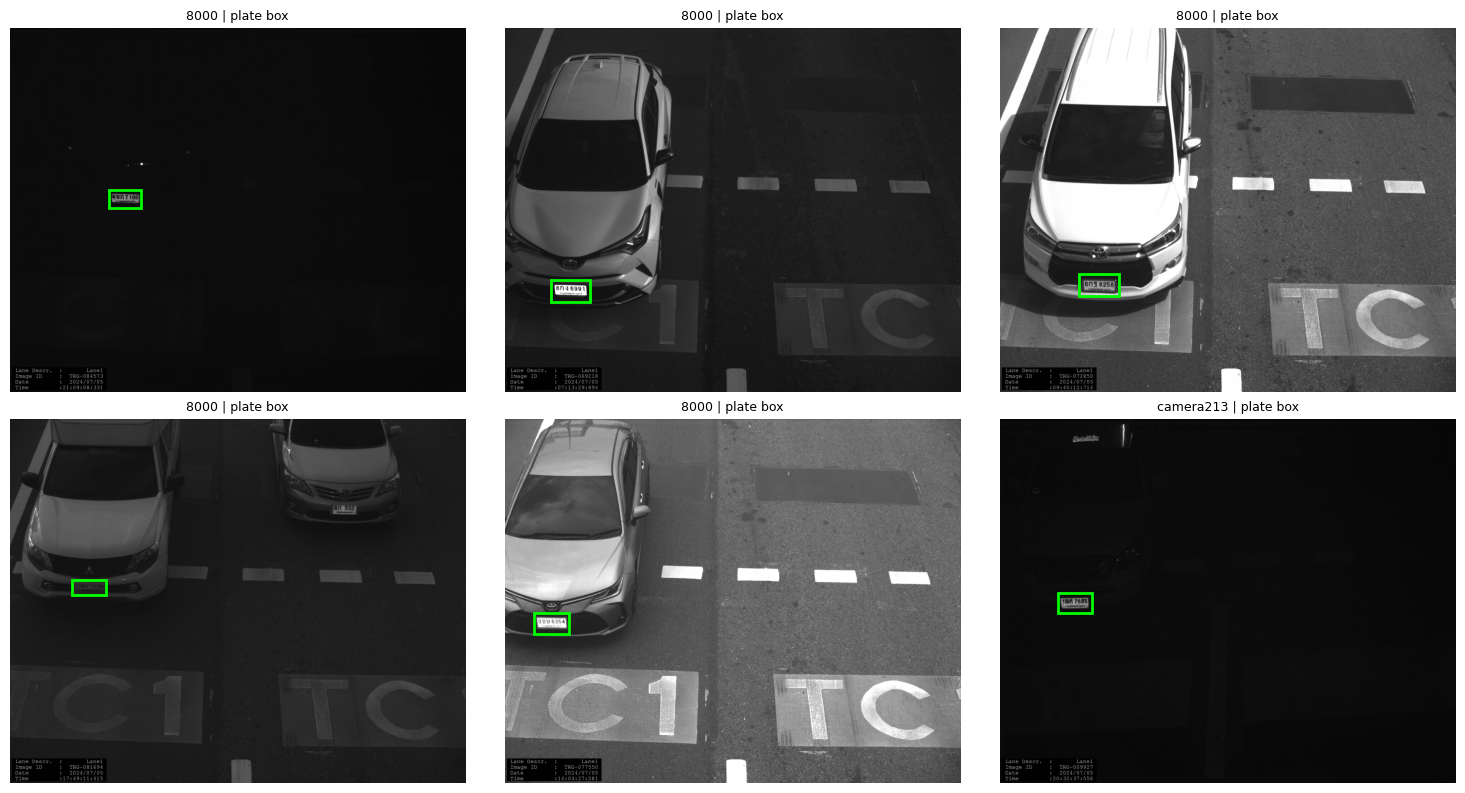

In [3]:
# 1) Visualize images with license-plate bbox on the full frame

def visualize_plate_boxes(df, num_samples=6, cols=3):
    if len(df) == 0:
        print('No rows to visualize')
        return
    take = min(num_samples, len(df))
    sample = df.sample(take, random_state=42)
    cols = max(1, cols)
    rows = (take + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).reshape(rows, cols)
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        try:
            img = load_image_cv2(row['img_path'])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]
            car_bbox = row['car_bbox_parsed']
            plate_rel = row['plate_bbox_parsed']
            if car_bbox is None or plate_rel is None:
                ax.axis('off')
                ax.set_title('missing bbox', fontsize=8)
                continue
            cx1, cy1, cx2, cy2 = car_bbox
            px1, py1, px2, py2 = plate_rel
            plate_abs = [px1 + cx1, py1 + cy1, px2 + cx1, py2 + cy1]
            plate_abs = clamp_bbox(plate_abs, w, h)
            x1, y1, x2, y2 = plate_abs
            ax.imshow(img_rgb)
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.set_title(f"{row['source']} | plate box", fontsize=9)
            ax.axis('off')
        except Exception as e:
            ax.axis('off')
            ax.set_title(f'error: {e}', fontsize=7)
    for ax in axes.flatten()[take:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_plate_boxes(all_df, num_samples=6, cols=3)

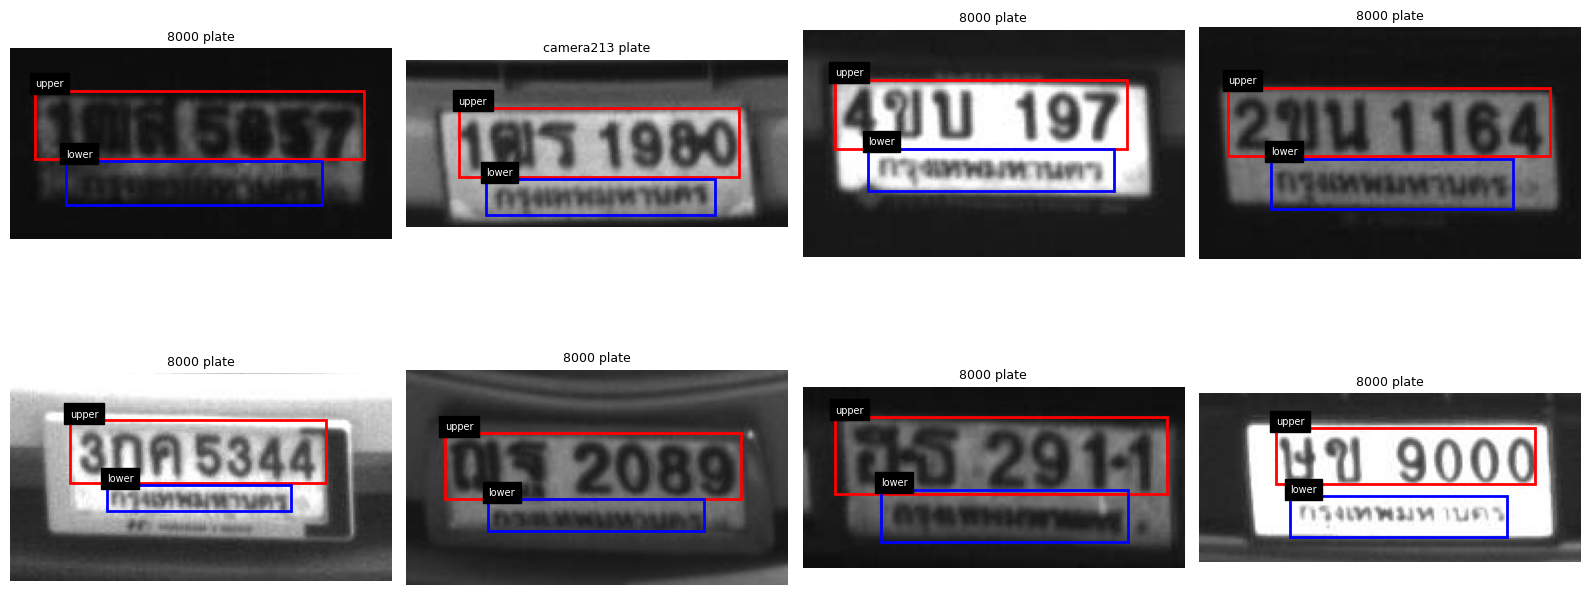

In [4]:
# 2) Visualize plate crop with upper/lower text boxes

def visualize_plate_text(df, num_samples=8, cols=4):
    if len(df) == 0:
        print('No rows to visualize')
        return
    take = min(num_samples, len(df))
    sample = df.sample(take, random_state=7)
    cols = max(1, cols)
    rows = (take + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).reshape(rows, cols)
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        try:
            img = load_image_cv2(row['img_path'])
            h, w = img.shape[:2]
            car_bbox = row['car_bbox_parsed']
            plate_rel = row['plate_bbox_parsed']
            char_polys = row['char_polys']
            if car_bbox is None or plate_rel is None or len(char_polys) == 0:
                ax.axis('off')
                ax.set_title('missing bbox', fontsize=8)
                continue
            cx1, cy1, cx2, cy2 = car_bbox
            px1, py1, px2, py2 = plate_rel
            plate_abs = [px1 + cx1, py1 + cy1, px2 + cx1, py2 + cy1]
            plate_abs = clamp_bbox(plate_abs, w, h)
            x1, y1, x2, y2 = map(int, plate_abs)
            if x2 <= x1 or y2 <= y1:
                ax.axis('off')
                ax.set_title('invalid plate box', fontsize=8)
                continue
            plate_crop = img[y1:y2, x1:x2]
            ph, pw = plate_crop.shape[:2]
            plate_crop_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)
            ax.imshow(plate_crop_rgb)
            # sort by y-center to treat first as upper, second as lower
            sorted_polys = sorted(char_polys, key=lambda p: np.mean(np.array(p)[:, 1]))
            for j, poly in enumerate(sorted_polys):
                box = polygon_to_xyxy(poly)
                box = clamp_bbox(box, pw, ph)
                bx1, by1, bx2, by2 = box
                if bx2 <= bx1 or by2 <= by1:
                    continue
                color = 'red' if j == 0 else 'blue'
                label = 'upper' if j == 0 else 'lower'
                rect = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1, linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(bx1, by1 - 2, label, color='white', fontsize=7, backgroundcolor='black')
            ax.set_title(f"{row['source']} plate", fontsize=9)
            ax.axis('off')
        except Exception as e:
            ax.axis('off')
            ax.set_title(f'error: {e}', fontsize=7)
    for ax in axes.flatten()[take:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_plate_text(all_df, num_samples=8, cols=4)

In [5]:
# 3) Crop upper/lower text pieces and store to disk

def crop_and_save_upper_lower(df, keep_max_regions=2, limit=None):
    OUTPUT_UPPER.mkdir(parents=True, exist_ok=True)
    OUTPUT_LOWER.mkdir(parents=True, exist_ok=True)
    rows = df[df['char_count'] <= keep_max_regions].copy()
    if limit is not None:
        rows = rows.head(limit)
    processed = 0
    saved_upper = 0
    saved_lower = 0
    skipped = 0

    for idx, row in rows.iterrows():
        try:
            img = load_image_cv2(row['img_path'])
            h, w = img.shape[:2]
            car_bbox = row['car_bbox_parsed']
            plate_rel = row['plate_bbox_parsed']
            char_polys = row['char_polys']
            if car_bbox is None or plate_rel is None or len(char_polys) == 0:
                skipped += 1
                continue
            cx1, cy1, cx2, cy2 = car_bbox
            px1, py1, px2, py2 = plate_rel
            plate_abs = [px1 + cx1, py1 + cy1, px2 + cx1, py2 + cy1]
            plate_abs = clamp_bbox(plate_abs, w, h)
            x1, y1, x2, y2 = map(int, plate_abs)
            if x2 <= x1 or y2 <= y1:
                skipped += 1
                continue
            plate_crop = img[y1:y2, x1:x2]
            ph, pw = plate_crop.shape[:2]
            sorted_polys = sorted(char_polys, key=lambda p: np.mean(np.array(p)[:, 1]))
            for j, poly in enumerate(sorted_polys):
                box = polygon_to_xyxy(poly)
                box = clamp_bbox(box, pw, ph)
                bx1, by1, bx2, by2 = map(int, box)
                if bx2 <= bx1 or by2 <= by1:
                    continue
                crop = plate_crop[by1:by2, bx1:bx2]
                if crop.size == 0:
                    continue
                label = 'upper' if j == 0 else 'lower'
                out_dir = OUTPUT_UPPER if j == 0 else OUTPUT_LOWER
                fname = f"{row['source']}_{idx}_{label}.jpg"
                save_image_cv2(out_dir / fname, crop)
                if j == 0:
                    saved_upper += 1
                else:
                    saved_lower += 1
            processed += 1
        except Exception as e:
            skipped += 1
            print(f"skip row {idx} ({row.get('img_path', '?')}) -> {e}")

    print(f"Processed rows: {processed}")
    print(f"Saved upper crops: {saved_upper}")
    print(f"Saved lower crops: {saved_lower}")
    print(f"Skipped rows: {skipped}")

# Set limit=None to process everything; keep_max_regions=2 skips truck plates with 3+ lines
crop_and_save_upper_lower(all_df, keep_max_regions=2, limit=None)

Processed rows: 10208
Saved upper crops: 10208
Saved lower crops: 10208
Skipped rows: 0


In [6]:
# 4) Build label CSVs for upper (CTC) and lower (province classifier)

import csv


def export_label_csvs(df, keep_max_regions=2, limit=None):
    rows = df[df['char_count'] <= keep_max_regions].copy()
    if limit is not None:
        rows = rows.head(limit)

    upper_records = []
    lower_records = []

    for idx, row in rows.iterrows():
        base_fields = {
            'source': row.get('source', ''),
            'transactionDate': row.get('transactionDate', ''),
            'plate': row.get('plate', ''),
            'province_code': row.get('province_code', ''),
            'province_description': row.get('province_description', ''),
            'brand_description': row.get('brand_description', ''),
            'colors_code': row.get('colors_code', ''),
            'colors_description': row.get('colors_description', ''),
            'vehicleClass': row.get('vehicleClass', ''),
        }

        upper_name = f"{row['source']}_{idx}_upper.jpg"
        lower_name = f"{row['source']}_{idx}_lower.jpg"

        upper_path = OUTPUT_UPPER / upper_name
        lower_path = OUTPUT_LOWER / lower_name

        if upper_path.exists():
            rec = {'filename': upper_name, 'label': row.get('plate', '')}
            rec.update(base_fields)
            upper_records.append(rec)
        if lower_path.exists():
            rec = {'filename': lower_name, 'label': row.get('province_description', '')}
            rec.update(base_fields)
            lower_records.append(rec)

    # Write CSVs without image_name/image_name_gray/car_bbox/plate_bbox/character_bbox
    upper_csv = OUTPUT_UPPER / 'labels.csv'
    lower_csv = OUTPUT_LOWER / 'labels.csv'

    if upper_records:
        with open(upper_csv, 'w', newline='', encoding='utf-8-sig') as f:
            writer = csv.DictWriter(f, fieldnames=list(upper_records[0].keys()))
            writer.writeheader()
            writer.writerows(upper_records)
        print(f"Upper labels saved: {upper_csv} ({len(upper_records)} rows)")
    else:
        print('No upper crops found to label (check that cropping cell was run).')

    if lower_records:
        with open(lower_csv, 'w', newline='', encoding='utf-8-sig') as f:
            writer = csv.DictWriter(f, fieldnames=list(lower_records[0].keys()))
            writer.writeheader()
            writer.writerows(lower_records)
        print(f"Lower labels saved: {lower_csv} ({len(lower_records)} rows)")
    else:
        print('No lower crops found to label (check that cropping cell was run).')


# Run to generate labels for existing crops; set limit if you only cropped a subset
export_label_csvs(all_df, keep_max_regions=2, limit=None)

Upper labels saved: C:\Users\Tanaphat\Desktop\Coding\ALPR\data\plate_upper\labels.csv (10208 rows)
Lower labels saved: C:\Users\Tanaphat\Desktop\Coding\ALPR\data\plate_lower\labels.csv (10208 rows)
